# ObjChange-MambaDiff — Finalisation / Resume Notebook

Run this notebook after a restart. It rebuilds the Python environment, redetects your datasets, then resumes from existing CSV/checkpoints under `D:\Datasets\Satillate\_objchange_mambadiff_full_experiment`.

Start from the first cell and run all cells.

In [2]:
# ============================================================
# 0. Imports and environment check
# ============================================================
# Required packages:
# pip install torch torchvision pillow numpy pandas matplotlib tqdm scikit-learn opencv-python

import os, sys, json, time, random, math, warnings, hashlib
from pathlib import Path
from dataclasses import dataclass, asdict
from collections import Counter, defaultdict
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

try:
    import cv2
    HAS_CV2=True
except Exception:
    HAS_CV2=False

print("Python:", sys.version)
print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.9.18 (main, Sep 11 2023, 14:09:26) [MSC v.1916 64 bit (AMD64)]
Torch: 2.5.1+cu121
CUDA: True
GPU: NVIDIA GeForce RTX 4060


In [3]:
# ============================================================
# 1. Configuration
# ============================================================

@dataclass
class CFG:
    ROOT: str = r"D:\Datasets\Satillate"
    PROJECT_NAME: str = "_objchange_mambadiff_full_experiment"
    SELECTED_DATASETS: tuple = ("LEVIR-CD", "S2Looking", "DSIFN-CD", "SECOND", "xView2")
    IMAGE_SIZE: int = 256
    BATCH_SIZE: int = 4
    NUM_WORKERS: int = 0
    EPOCHS: int = 50
    LR: float = 1e-4
    WEIGHT_DECAY: float = 1e-4
    AMP: bool = True
    SEED: int = 42
    MAX_TRAIN_SAMPLES: object = None
    MAX_VAL_SAMPLES: object = None
    MAX_TEST_SAMPLES: object = None
    RUN_MAIN_BENCHMARK: bool = True
    RUN_LABEL_EFFICIENCY: bool = True
    RUN_CROSS_DATASET: bool = True
    RUN_ABLATION: bool = True
    LABEL_FRACTIONS: tuple = (0.01, 0.05, 0.10, 0.25, 0.50, 1.00)
    LABEL_EFF_EPOCHS: int = 25
    CROSS_EPOCHS: int = 25
    MAIN_MODELS: tuple = ("SiameseUNet", "ObjChangeMambaDiffLite")
    CHANGE_THRESHOLD: float = 0.5
    POS_WEIGHT_CLAMP: float = 10.0
    QUALITATIVE_N: int = 8

cfg = CFG()
ROOT = Path(cfg.ROOT)
OUT_DIR = ROOT / cfg.PROJECT_NAME
for sub in ["reports", "checkpoints", "figures", "qualitative_predictions", "cache_masks", "logs"]:
    (OUT_DIR / sub).mkdir(parents=True, exist_ok=True)

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

set_seed(cfg.SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("ROOT:", ROOT, "exists=", ROOT.exists())
print("OUT_DIR:", OUT_DIR)
print("DEVICE:", device)
print(json.dumps(asdict(cfg), indent=2, default=str))

ROOT: D:\Datasets\Satillate exists= True
OUT_DIR: D:\Datasets\Satillate\_objchange_mambadiff_full_experiment
DEVICE: cuda
{
  "ROOT": "D:\\Datasets\\Satillate",
  "PROJECT_NAME": "_objchange_mambadiff_full_experiment",
  "SELECTED_DATASETS": [
    "LEVIR-CD",
    "S2Looking",
    "DSIFN-CD",
    "SECOND",
    "xView2"
  ],
  "IMAGE_SIZE": 256,
  "BATCH_SIZE": 4,
  "NUM_WORKERS": 0,
  "EPOCHS": 50,
  "LR": 0.0001,
  "WEIGHT_DECAY": 0.0001,
  "AMP": true,
  "SEED": 42,
  "MAX_TRAIN_SAMPLES": null,
  "MAX_VAL_SAMPLES": null,
  "MAX_TEST_SAMPLES": null,
  "RUN_MAIN_BENCHMARK": true,
  "RUN_LABEL_EFFICIENCY": true,
  "RUN_CROSS_DATASET": true,
  "RUN_ABLATION": true,
  "LABEL_FRACTIONS": [
    0.01,
    0.05,
    0.1,
    0.25,
    0.5,
    1.0
  ],
  "LABEL_EFF_EPOCHS": 25,
  "CROSS_EPOCHS": 25,
  "MAIN_MODELS": [
    "SiameseUNet",
    "ObjChangeMambaDiffLite"
  ],
  "CHANGE_THRESHOLD": 0.5,
  "POS_WEIGHT_CLAMP": 10.0,
  "QUALITATIVE_N": 8
}


In [4]:
# ============================================================
# 2. Dataset discovery and pairing
# ============================================================

IMG_EXTS={".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp", ".webp"}
JSON_EXTS={".json"}
DATASET_ALIASES={
    "LEVIR-CD":["levir", "levircd", "levir-cd", "levir cd"],
    "WHU-CD":["whu", "whucd", "whu-cd", "buildingchange"],
    "DSIFN-CD":["dsifn", "dsifncd", "dsifn-cd"],
    "CDD":["cdd", "changedetectiondataset", "change detection dataset"],
    "SECOND":["second"],
    "HRSCD":["hrscd"],
    "xView2":["xview2", "xbd", "xview"],
    "S2Looking":["s2looking", "s2 looking"]
}

def norm_name(s):
    return str(s).lower().replace(" ","").replace("-","").replace("_","")

def list_files(root, exts=None):
    root=Path(root)
    if not root.exists(): return []
    out=[]
    for p in root.rglob("*"):
        if p.is_file() and (exts is None or p.suffix.lower() in exts):
            out.append(p)
    return out

def infer_split(path):
    parts=[norm_name(x) for x in Path(path).parts]
    if any(x in ["train","training","trainset"] for x in parts): return "train"
    if any(x in ["val","valid","validation","valset"] for x in parts): return "val"
    if any(x in ["test","testing","testset"] for x in parts): return "test"
    return "unknown"

def common_stem(p):
    s=Path(p).stem
    for token in ["_pre_disaster","_post_disaster","_pre","_post","_A","_B","_label","_mask","_change"]:
        s=s.replace(token,"")
    return s

def find_dataset_roots(root):
    root=Path(root)
    candidates=[]
    search_dirs=[]
    if root.exists():
        search_dirs.append(root)
        search_dirs += [p for p in root.iterdir() if p.is_dir()]
        search_dirs += [p for p in root.glob("*/*") if p.is_dir()]
    for p in search_dirs:
        low=norm_name(p.name)
        for ds, aliases in DATASET_ALIASES.items():
            if any(norm_name(a) in low for a in aliases):
                candidates.append({"dataset":ds,"path":p,"reason":"name_match"})
    seen=set(); out=[]
    for c in candidates:
        key=(c["dataset"], str(c["path"]).lower())
        if key not in seen:
            out.append(c); seen.add(key)
    return out

def detect_role_folders(ds_root):
    roles={"A":[],"B":[],"MASK":[],"SEM1":[],"SEM2":[]}
    for f in Path(ds_root).rglob("*"):
        if not f.is_dir(): continue
        n=norm_name(f.name); text=norm_name(str(f.relative_to(ds_root)))
        if n in ["a","t1","time1","img1","image1","im1","before","pre","predisaster"] or "image1" in text or "time1" in text:
            roles["A"].append(f)
        if n in ["b","t2","time2","img2","image2","im2","after","post","postdisaster"] or "image2" in text or "time2" in text:
            roles["B"].append(f)
        if any(h in n for h in ["label","mask","gt","change"]):
            if any(x in n for x in ["2006","2012","landcover","land_cover"]):
                if "2006" in n or "t1" in n or "time1" in n: roles["SEM1"].append(f)
                if "2012" in n or "t2" in n or "time2" in n: roles["SEM2"].append(f)
            else:
                roles["MASK"].append(f)
    return roles

def pair_from_role_folders(dataset, ds_root):
    roles=detect_role_folders(ds_root)
    records=[]
    # binary pair A/B/mask
    for af in roles["A"]:
        split=infer_split(af)
        b_cands=sorted(roles["B"], key=lambda x:(infer_split(x)!=split, len(str(x))))
        m_cands=sorted(roles["MASK"], key=lambda x:(infer_split(x)!=split, len(str(x))))
        if not b_cands: continue
        bf=b_cands[0]
        mf=m_cands[0] if m_cands else None
        A={common_stem(p):p for p in list_files(af, IMG_EXTS)}
        B={common_stem(p):p for p in list_files(bf, IMG_EXTS)}
        M={common_stem(p):p for p in list_files(mf, IMG_EXTS)} if mf else {}
        for st in sorted(set(A)&set(B)):
            if st in M:
                records.append({"dataset":dataset,"split":split if split!="unknown" else infer_split(A[st]),"image_t1":A[st],"image_t2":B[st],"mask":M[st],"sem_t1":None,"sem_t2":None,"json":None,"source_root":ds_root})
    # semantic pair, convert semantic map difference to binary change
    if roles["SEM1"] and roles["SEM2"] and roles["A"] and roles["B"]:
        for af in roles["A"][:3]:
            split=infer_split(af)
            bf=sorted(roles["B"], key=lambda x:(infer_split(x)!=split, len(str(x))))[0]
            s1f=sorted(roles["SEM1"], key=lambda x:(infer_split(x)!=split, len(str(x))))[0]
            s2f=sorted(roles["SEM2"], key=lambda x:(infer_split(x)!=split, len(str(x))))[0]
            A={common_stem(p):p for p in list_files(af, IMG_EXTS)}
            B={common_stem(p):p for p in list_files(bf, IMG_EXTS)}
            S1={common_stem(p):p for p in list_files(s1f, IMG_EXTS)}
            S2={common_stem(p):p for p in list_files(s2f, IMG_EXTS)}
            for st in sorted(set(A)&set(B)&set(S1)&set(S2)):
                records.append({"dataset":dataset,"split":split,"image_t1":A[st],"image_t2":B[st],"mask":None,"sem_t1":S1[st],"sem_t2":S2[st],"json":None,"source_root":ds_root})
    return records

def pair_xview2(dataset, ds_root):
    files=list_files(ds_root, IMG_EXTS)
    pre={}; post={}
    for p in files:
        name=p.name.lower(); st=common_stem(p)
        if "pre_disaster" in name or "_pre_" in name or name.endswith("_pre.png"):
            pre[st]=p
        if "post_disaster" in name or "_post_" in name or name.endswith("_post.png"):
            post[st]=p
    jsons={common_stem(p):p for p in list_files(ds_root, JSON_EXTS)}
    recs=[]
    for st in sorted(set(pre)&set(post)):
        j=jsons.get(st) or jsons.get(st+"_post_disaster") or jsons.get(st+"_pre_disaster")
        recs.append({"dataset":dataset,"split":infer_split(pre[st]),"image_t1":pre[st],"image_t2":post[st],"mask":None,"sem_t1":None,"sem_t2":None,"json":j,"source_root":ds_root})
    return recs

def build_dataset_records(dataset, ds_root):
    recs = pair_xview2(dataset, ds_root) if dataset=="xView2" else pair_from_role_folders(dataset, ds_root)
    if recs and all(r["split"]=="unknown" for r in recs):
        idx=list(range(len(recs))); random.Random(cfg.SEED).shuffle(idx)
        n=len(idx); ntr=int(0.7*n); nv=int(0.15*n)
        for k,i in enumerate(idx):
            recs[i]["split"] = "train" if k<ntr else ("val" if k<ntr+nv else "test")
    return recs

dataset_candidates=find_dataset_roots(ROOT)
pd.DataFrame(dataset_candidates).to_csv(OUT_DIR/"reports"/"dataset_candidates.csv", index=False)
print(pd.DataFrame(dataset_candidates) if dataset_candidates else "No dataset candidates")

all_records=[]
for c in dataset_candidates:
    recs=build_dataset_records(c["dataset"], c["path"])
    print(c["dataset"], c["path"], "paired records:", len(recs))
    all_records += recs
seen=set(); unique=[]
for r in all_records:
    key=(r["dataset"],str(r["image_t1"]).lower(),str(r["image_t2"]).lower(),str(r.get("mask")).lower())
    if key not in seen:
        unique.append(r); seen.add(key)
all_records=unique
records_df=pd.DataFrame([{k:str(v) for k,v in r.items()} for r in all_records])
records_df.to_csv(OUT_DIR/"reports"/"paired_records.csv", index=False)
print("Total paired records:", len(all_records))
if len(records_df): display(records_df.groupby(["dataset","split"]).size().reset_index(name="n"))

     dataset                                               path      reason
0     WHU-CD  D:\Datasets\Satillate\Building change detectio...  name_match
1        CDD  D:\Datasets\Satillate\Building change detectio...  name_match
2   DSIFN-CD             D:\Datasets\Satillate\DSIFN Train Test  name_match
3      HRSCD                        D:\Datasets\Satillate\HRSCD  name_match
4   LEVIR-CD                     D:\Datasets\Satillate\LEVIR CD  name_match
5  S2Looking                    D:\Datasets\Satillate\S2Looking  name_match
6     SECOND                       D:\Datasets\Satillate\SECOND  name_match
7     SECOND               D:\Datasets\Satillate\second_dataset  name_match
8     xView2                       D:\Datasets\Satillate\xView2  name_match
WHU-CD D:\Datasets\Satillate\Building change detection dataset_add paired records: 0
CDD D:\Datasets\Satillate\Building change detection dataset_add paired records: 0
DSIFN-CD D:\Datasets\Satillate\DSIFN Train Test paired records: 14434
HRS

,dataset,split,n
0,DSIFN-CD,test,2488
1,DSIFN-CD,train,11946
2,LEVIR-CD,test,128
3,LEVIR-CD,train,445
4,LEVIR-CD,val,64
5,S2Looking,test,1000
6,S2Looking,train,3500
7,S2Looking,val,500
8,SECOND,test,3388
9,SECOND,train,2968


In [5]:
# ============================================================
# 3. Dataset class and loaders
# ============================================================

def read_img(path, size, is_mask=False):
    with Image.open(path) as im:
        if is_mask:
            im=im.convert("L").resize((size,size), Image.NEAREST)
            arr=np.array(im)
            return (arr>0).astype(np.float32)
        im=im.convert("RGB").resize((size,size), Image.BILINEAR)
        arr=np.array(im).astype(np.float32)/255.0
        return np.transpose(arr,(2,0,1))

def sem_diff_mask(path1, path2, size):
    return (read_img(path1,size,True)!=read_img(path2,size,True)).astype(np.float32)

def hash12(x): return hashlib.md5(str(x).encode()).hexdigest()[:12]

def xview2_json_to_mask(json_path, image_path, out_path, size):
    if json_path is None or not Path(json_path).exists(): return None
    out_path=Path(out_path)
    if out_path.exists(): return out_path
    try:
        with Image.open(image_path) as im: W,H=im.size
        canvas=Image.new("L", (W,H), 0); draw=ImageDraw.Draw(canvas)
        data=json.load(open(json_path,"r",encoding="utf-8"))
        feats=data.get("features",{}).get("xy",[]) if isinstance(data.get("features",{}), dict) else []
        for feat in feats:
            wkt=feat.get("wkt","")
            if "POLYGON" not in wkt.upper(): continue
            txt=wkt.replace("POLYGON","").replace("((","").replace("))","").replace("(","").replace(")","")
            pts=[]
            for pair in txt.split(","):
                sp=pair.strip().split()
                if len(sp)>=2:
                    try: pts.append((float(sp[0]), float(sp[1])))
                    except Exception: pass
            if len(pts)>=3: draw.polygon(pts, fill=1)
        canvas=canvas.resize((size,size), Image.NEAREST)
        out_path.parent.mkdir(parents=True, exist_ok=True)
        canvas.save(out_path)
        return out_path
    except Exception:
        return None

class ChangeDataset(Dataset):
    def __init__(self, records, image_size=256, augment=False):
        self.records=list(records); self.image_size=image_size; self.augment=augment
    def __len__(self): return len(self.records)
    def aug(self,x1,x2,y):
        if random.random()<0.5: x1=x1[:,:,::-1].copy(); x2=x2[:,:,::-1].copy(); y=y[:,::-1].copy()
        if random.random()<0.5: x1=x1[:,::-1,:].copy(); x2=x2[:,::-1,:].copy(); y=y[::-1,:].copy()
        if random.random()<0.5:
            k=random.choice([1,2,3]); x1=np.rot90(x1,k,(1,2)).copy(); x2=np.rot90(x2,k,(1,2)).copy(); y=np.rot90(y,k,(0,1)).copy()
        if random.random()<0.25:
            f=random.uniform(0.85,1.15); x1=np.clip(x1*f,0,1); x2=np.clip(x2*f,0,1)
        return x1,x2,y
    def __getitem__(self,idx):
        r=self.records[idx]
        x1=read_img(r["image_t1"], self.image_size, False)
        x2=read_img(r["image_t2"], self.image_size, False)
        if r.get("mask") and str(r.get("mask"))!="None" and Path(r["mask"]).exists():
            y=read_img(r["mask"], self.image_size, True)
        elif r.get("sem_t1") and r.get("sem_t2"):
            y=sem_diff_mask(r["sem_t1"], r["sem_t2"], self.image_size)
        elif r.get("dataset")=="xView2" and r.get("json"):
            mp=OUT_DIR/"cache_masks"/"xview2"/(hash12(r["image_t2"])+".png")
            made=xview2_json_to_mask(r["json"], r["image_t2"], mp, self.image_size)
            if made: y=read_img(made, self.image_size, True)
            else:
                diff=np.mean(np.abs(x2-x1), axis=0); y=(diff>np.quantile(diff,0.95)).astype(np.float32)
        else:
            diff=np.mean(np.abs(x2-x1), axis=0); y=(diff>np.quantile(diff,0.95)).astype(np.float32)
        if self.augment: x1,x2,y=self.aug(x1,x2,y)
        return {"image_t1":torch.tensor(x1,dtype=torch.float32),"image_t2":torch.tensor(x2,dtype=torch.float32),"mask":torch.tensor(y[None],dtype=torch.float32),"dataset":r.get("dataset","unknown"),"id":Path(r["image_t1"]).stem}

def maybe_limit(records, max_n, seed=42):
    if max_n is None or len(records)<=max_n: return records
    rng=random.Random(seed); idx=list(range(len(records))); rng.shuffle(idx); idx=sorted(idx[:max_n])
    return [records[i] for i in idx]

def get_records(dataset, split):
    recs=[r for r in all_records if r["dataset"]==dataset and r["split"]==split]
    if split=="val" and not recs:
        tr=[r for r in all_records if r["dataset"]==dataset and r["split"]=="train"]
        if len(tr)>10: return tr[:max(1,int(0.15*len(tr)))]
    if split=="test" and not recs:
        va=[r for r in all_records if r["dataset"]==dataset and r["split"]=="val"]
        return va
    return recs

def make_loaders(dataset, max_train=None, max_val=None, max_test=None, batch_size=None):
    batch_size=batch_size or cfg.BATCH_SIZE
    tr=maybe_limit(get_records(dataset,"train"), max_train if max_train is not None else cfg.MAX_TRAIN_SAMPLES, cfg.SEED)
    va=maybe_limit(get_records(dataset,"val"), max_val if max_val is not None else cfg.MAX_VAL_SAMPLES, cfg.SEED)
    te=maybe_limit(get_records(dataset,"test"), max_test if max_test is not None else cfg.MAX_TEST_SAMPLES, cfg.SEED)
    if not va and te: va=te[:max(1,min(len(te), len(te)//2))]
    loaders={}
    for split,recs,aug in [("train",tr,True),("val",va,False),("test",te,False)]:
        loaders[split]=DataLoader(ChangeDataset(recs,cfg.IMAGE_SIZE,aug),batch_size=batch_size,shuffle=(split=="train"),num_workers=cfg.NUM_WORKERS,pin_memory=torch.cuda.is_available()) if recs else None
    print(dataset, "train/val/test:", len(tr), len(va), len(te))
    return loaders, {"train":tr,"val":va,"test":te}

detected_datasets=sorted(set(r["dataset"] for r in all_records))
selected=[d for d in cfg.SELECTED_DATASETS if d in detected_datasets]
print("Detected:", detected_datasets)
print("Selected:", selected)

Detected: ['DSIFN-CD', 'LEVIR-CD', 'S2Looking', 'SECOND', 'xView2']
Selected: ['LEVIR-CD', 'S2Looking', 'DSIFN-CD', 'SECOND', 'xView2']


In [6]:
# ============================================================
# 5. Models
# ============================================================

class ConvBlock(nn.Module):
    def __init__(self, ic, oc, drop=0.0):
        super().__init__()
        self.net=nn.Sequential(nn.Conv2d(ic,oc,3,padding=1,bias=False),nn.BatchNorm2d(oc),nn.ReLU(True),nn.Conv2d(oc,oc,3,padding=1,bias=False),nn.BatchNorm2d(oc),nn.ReLU(True),nn.Dropout2d(drop) if drop>0 else nn.Identity())
    def forward(self,x): return self.net(x)

class Encoder(nn.Module):
    def __init__(self, base=32, drop=0.05):
        super().__init__(); self.pool=nn.MaxPool2d(2)
        self.c1=ConvBlock(3,base,drop); self.c2=ConvBlock(base,base*2,drop); self.c3=ConvBlock(base*2,base*4,drop); self.c4=ConvBlock(base*4,base*8,drop)
    def forward(self,x):
        f1=self.c1(x); f2=self.c2(self.pool(f1)); f3=self.c3(self.pool(f2)); f4=self.c4(self.pool(f3)); return [f1,f2,f3,f4]

class UpBlock(nn.Module):
    def __init__(self, ic, sc, oc, drop=0.0):
        super().__init__(); self.up=nn.ConvTranspose2d(ic,oc,2,2); self.conv=ConvBlock(oc+sc,oc,drop)
    def forward(self,x,s):
        x=self.up(x)
        if x.shape[-2:]!=s.shape[-2:]: x=F.interpolate(x,size=s.shape[-2:],mode="bilinear",align_corners=False)
        return self.conv(torch.cat([x,s],1))

class SiameseUNet(nn.Module):
    def __init__(self, base=32, drop=0.05):
        super().__init__(); self.enc=Encoder(base,drop)
        self.f1=ConvBlock(base*3,base,drop); self.f2=ConvBlock(base*2*3,base*2,drop); self.f3=ConvBlock(base*4*3,base*4,drop); self.f4=ConvBlock(base*8*3,base*8,drop)
        self.u3=UpBlock(base*8,base*4,base*4,drop); self.u2=UpBlock(base*4,base*2,base*2,drop); self.u1=UpBlock(base*2,base,base,drop); self.head=nn.Conv2d(base,1,1)
    def fuse(self,a,b,layer): return layer(torch.cat([a,b,torch.abs(a-b)],1))
    def forward(self,x1,x2):
        A=self.enc(x1); B=self.enc(x2)
        f1=self.fuse(A[0],B[0],self.f1); f2=self.fuse(A[1],B[1],self.f2); f3=self.fuse(A[2],B[2],self.f3); f4=self.fuse(A[3],B[3],self.f4)
        x=self.u3(f4,f3); x=self.u2(x,f2); x=self.u1(x,f1); return self.head(x)

class LightweightMambaMixer(nn.Module):
    def __init__(self, dim):
        super().__init__(); self.norm=nn.LayerNorm(dim); self.inp=nn.Linear(dim,dim*2); self.dw=nn.Conv1d(dim,dim,5,padding=2,groups=dim); self.gate=nn.Linear(dim,dim); self.out=nn.Linear(dim,dim)
    def forward(self,x):
        z=self.norm(x); a,b=self.inp(z).chunk(2,-1); a=self.dw(a.transpose(1,2)).transpose(1,2); g=torch.sigmoid(self.gate(b)); return x+self.out(torch.tanh(a)*g)

class ObjectTokenBlock(nn.Module):
    def __init__(self, ch, grid=8):
        super().__init__(); self.grid=grid; self.mix=LightweightMambaMixer(ch); self.proj=nn.Sequential(nn.Conv2d(ch*2,ch,1),nn.BatchNorm2d(ch),nn.ReLU(True))
    def forward(self,f):
        B,C,H,W=f.shape; p=F.adaptive_avg_pool2d(f,(self.grid,self.grid)); tok=p.flatten(2).transpose(1,2); tok=self.mix(tok); obj=tok.transpose(1,2).reshape(B,C,self.grid,self.grid); obj=F.interpolate(obj,size=(H,W),mode="bilinear",align_corners=False); return self.proj(torch.cat([f,obj],1))

class ObjChangeMambaDiffLite(nn.Module):
    def __init__(self, base=32, drop=0.10, use_object=True, use_mamba=True):
        super().__init__(); self.use_mamba=use_mamba; self.enc=Encoder(base,drop)
        self.f1=ConvBlock(base*4,base,drop); self.f2=ConvBlock(base*2*4,base*2,drop); self.f3=ConvBlock(base*4*4,base*4,drop); self.f4=ConvBlock(base*8*4,base*8,drop)
        self.o3=ObjectTokenBlock(base*4) if use_object else nn.Identity(); self.o4=ObjectTokenBlock(base*8) if use_object else nn.Identity(); self.m4=LightweightMambaMixer(base*8) if use_mamba else nn.Identity()
        self.u3=UpBlock(base*8,base*4,base*4,drop); self.u2=UpBlock(base*4,base*2,base*2,drop); self.u1=UpBlock(base*2,base,base,drop); self.drop=nn.Dropout2d(drop); self.head=nn.Conv2d(base,1,1)
    def fuse(self,a,b,layer): return layer(torch.cat([a,b,torch.abs(a-b),a*b],1))
    def forward(self,x1,x2):
        A=self.enc(x1); B=self.enc(x2)
        f1=self.fuse(A[0],B[0],self.f1); f2=self.fuse(A[1],B[1],self.f2); f3=self.o3(self.fuse(A[2],B[2],self.f3)); f4=self.o4(self.fuse(A[3],B[3],self.f4))
        if self.use_mamba:
            Bn,C,H,W=f4.shape; tok=f4.flatten(2).transpose(1,2); tok=self.m4(tok); f4=tok.transpose(1,2).reshape(Bn,C,H,W)
        x=self.u3(f4,f3); x=self.u2(x,f2); x=self.u1(x,f1); return self.head(self.drop(x))

def build_model(name):
    if name=="SiameseUNet": return SiameseUNet()
    if name=="ObjChangeMambaDiffLite": return ObjChangeMambaDiffLite(use_object=True,use_mamba=True)
    if name=="ObjChange_noObject": return ObjChangeMambaDiffLite(use_object=False,use_mamba=True)
    if name=="ObjChange_noMamba": return ObjChangeMambaDiffLite(use_object=True,use_mamba=False)
    if name=="ObjChange_noObject_noMamba": return ObjChangeMambaDiffLite(use_object=False,use_mamba=False)
    raise ValueError(name)

with torch.no_grad():
    m=build_model("ObjChangeMambaDiffLite").to(device)
    y=m(torch.randn(1,3,cfg.IMAGE_SIZE,cfg.IMAGE_SIZE,device=device), torch.randn(1,3,cfg.IMAGE_SIZE,cfg.IMAGE_SIZE,device=device))
    print("Model output:", y.shape)
    del m,y
    if torch.cuda.is_available(): torch.cuda.empty_cache()

Model output: torch.Size([1, 1, 256, 256])


In [7]:
# ============================================================
# 6. Loss, metrics, training and evaluation
# ============================================================

class DiceBCELoss(nn.Module):
    def __init__(self, pos_weight=1.0, smooth=1.0):
        super().__init__(); self.smooth=smooth; self.register_buffer("pw", torch.tensor([float(pos_weight)]))
    def forward(self, logits, y):
        bce=F.binary_cross_entropy_with_logits(logits,y,pos_weight=self.pw.to(logits.device))
        p=torch.sigmoid(logits); inter=(p*y).sum((1,2,3)); den=p.sum((1,2,3))+y.sum((1,2,3)); dice=1-((2*inter+self.smooth)/(den+self.smooth)).mean()
        return bce+dice

def estimate_pos_weight(loader, max_batches=20):
    pos=0; neg=0
    for i,b in enumerate(loader):
        y=b["mask"]; pos+=float(y.sum()); neg+=float(y.numel()-y.sum())
        if i+1>=max_batches: break
    return 1.0 if pos<=0 else min(neg/pos, cfg.POS_WEIGHT_CLAMP)

def metrics_from_logits(logits,y,thr=0.5):
    probs=torch.sigmoid(logits).detach().cpu().numpy().ravel(); gt=y.detach().cpu().numpy().ravel().astype(np.uint8); pr=(probs>=thr).astype(np.uint8)
    tp=int(((pr==1)&(gt==1)).sum()); fp=int(((pr==1)&(gt==0)).sum()); fn=int(((pr==0)&(gt==1)).sum()); tn=int(((pr==0)&(gt==0)).sum())
    precision=tp/(tp+fp+1e-8); recall=tp/(tp+fn+1e-8); f1=2*precision*recall/(precision+recall+1e-8); iou=tp/(tp+fp+fn+1e-8); acc=(tp+tn)/(tp+tn+fp+fn+1e-8)
    pe=((tp+fp)*(tp+fn)+(fn+tn)*(fp+tn))/((tp+tn+fp+fn+1e-8)**2); kappa=(acc-pe)/(1-pe+1e-8)
    conf=np.maximum(probs,1-probs); correct=(pr==gt).astype(np.float32); ece=0.0
    for lo,hi in zip(np.linspace(0,1,11)[:-1], np.linspace(0,1,11)[1:]):
        m=(conf>=lo)&(conf<hi)
        if m.any(): ece += m.mean()*abs(correct[m].mean()-conf[m].mean())
    return {"tp":tp,"fp":fp,"fn":fn,"tn":tn,"precision":precision,"recall":recall,"f1":f1,"iou":iou,"accuracy":acc,"kappa":kappa,"ece":ece}

def aggregate(ms):
    if not ms: return {}
    tp=sum(m["tp"] for m in ms); fp=sum(m["fp"] for m in ms); fn=sum(m["fn"] for m in ms); tn=sum(m["tn"] for m in ms)
    precision=tp/(tp+fp+1e-8); recall=tp/(tp+fn+1e-8); f1=2*precision*recall/(precision+recall+1e-8); iou=tp/(tp+fp+fn+1e-8); acc=(tp+tn)/(tp+tn+fp+fn+1e-8)
    pe=((tp+fp)*(tp+fn)+(fn+tn)*(fp+tn))/((tp+tn+fp+fn+1e-8)**2); kappa=(acc-pe)/(1-pe+1e-8)
    return {"precision":precision,"recall":recall,"f1":f1,"iou":iou,"accuracy":acc,"kappa":kappa,"ece":float(np.mean([m["ece"] for m in ms])),"tp":tp,"fp":fp,"fn":fn,"tn":tn}

def train_one_epoch(model, loader, opt, criterion, scaler):
    model.train(); losses=[]
    for b in tqdm(loader, leave=False, desc="train"):
        x1=b["image_t1"].to(device); x2=b["image_t2"].to(device); y=b["mask"].to(device)
        opt.zero_grad(set_to_none=True); use_amp=cfg.AMP and torch.cuda.is_available()
        with autocast(enabled=use_amp): loss=criterion(model(x1,x2),y)
        if use_amp:
            scaler.scale(loss).backward(); scaler.unscale_(opt); torch.nn.utils.clip_grad_norm_(model.parameters(),1.0); scaler.step(opt); scaler.update()
        else:
            loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(),1.0); opt.step()
        losses.append(float(loss.item()))
    return float(np.mean(losses)) if losses else np.nan

@torch.no_grad()
def evaluate(model, loader, criterion=None):
    model.eval(); losses=[]; ms=[]
    for b in tqdm(loader, leave=False, desc="eval"):
        x1=b["image_t1"].to(device); x2=b["image_t2"].to(device); y=b["mask"].to(device)
        logits=model(x1,x2)
        if criterion: losses.append(float(criterion(logits,y).item()))
        ms.append(metrics_from_logits(logits,y,cfg.CHANGE_THRESHOLD))
    out=aggregate(ms); out["loss"]=float(np.mean(losses)) if losses else np.nan
    return out

@torch.no_grad()
def save_qualitative(model, loader, out_dir, max_items=8):
    out_dir=Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True); model.eval(); saved=0
    for b in loader:
        x1=b["image_t1"].to(device); x2=b["image_t2"].to(device); y=b["mask"].to(device); prob=torch.sigmoid(model(x1,x2)); pred=(prob>=cfg.CHANGE_THRESHOLD).float()
        for i in range(x1.shape[0]):
            fig,axs=plt.subplots(1,5,figsize=(15,3))
            axs[0].imshow(x1[i].cpu().permute(1,2,0)); axs[0].set_title("T1")
            axs[1].imshow(x2[i].cpu().permute(1,2,0)); axs[1].set_title("T2")
            axs[2].imshow(y[i,0].cpu(),cmap="gray"); axs[2].set_title("GT")
            axs[3].imshow(prob[i,0].cpu(),cmap="magma"); axs[3].set_title("Prob")
            axs[4].imshow(pred[i,0].cpu(),cmap="gray"); axs[4].set_title("Pred")
            for ax in axs: ax.axis("off")
            plt.tight_layout(); fig.savefig(out_dir/f"qual_{saved:03d}.png", dpi=160); plt.close(fig)
            saved+=1
            if saved>=max_items: return saved
    return saved

def train_model_on_dataset(model_name, dataset_name, epochs, experiment_tag="main", max_train=None, max_val=None, max_test=None):
    loaders,_=make_loaders(dataset_name,max_train=max_train,max_val=max_val,max_test=max_test)
    if loaders["train"] is None or loaders["val"] is None:
        print("Skipping missing loaders", dataset_name); return None
    model=build_model(model_name).to(device)
    criterion=DiceBCELoss(estimate_pos_weight(loaders["train"]))
    opt=torch.optim.AdamW(model.parameters(),lr=cfg.LR,weight_decay=cfg.WEIGHT_DECAY)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=max(1,epochs)); scaler=GradScaler(enabled=cfg.AMP and torch.cuda.is_available())
    best=-1; best_path=OUT_DIR/"checkpoints"/(f"{experiment_tag}_{dataset_name}_{model_name}_best.pt".replace("/","_")); hist=[]; start=time.time()
    for ep in range(1,epochs+1):
        tl=train_one_epoch(model,loaders["train"],opt,criterion,scaler); vm=evaluate(model,loaders["val"],criterion); sch.step()
        hist.append({"experiment":experiment_tag,"dataset":dataset_name,"model":model_name,"epoch":ep,"train_loss":tl,**{f"val_{k}":v for k,v in vm.items() if k not in ["tp","fp","fn","tn"]}})
        print(f"[{experiment_tag}] {dataset_name} {model_name} epoch {ep}/{epochs} train_loss={tl:.4f} val_f1={vm.get('f1',0):.4f} val_iou={vm.get('iou',0):.4f}")
        if vm.get("f1",0)>best:
            best=vm["f1"]; torch.save({"model_state":model.state_dict(),"model_name":model_name,"dataset":dataset_name,"cfg":asdict(cfg),"val_metrics":vm}, best_path)
    if best_path.exists(): model.load_state_dict(torch.load(best_path,map_location=device)["model_state"])
    tm=evaluate(model, loaders["test"] or loaders["val"], criterion)
    save_qualitative(model, loaders["test"] or loaders["val"], OUT_DIR/"qualitative_predictions"/experiment_tag/dataset_name/model_name, cfg.QUALITATIVE_N)
    pd.DataFrame(hist).to_csv(OUT_DIR/"logs"/(f"{experiment_tag}_{dataset_name}_{model_name}_history.csv".replace("/","_")), index=False)
    res={"experiment":experiment_tag,"dataset":dataset_name,"model":model_name,"epochs":epochs,"best_val_f1":best,"test_precision":tm.get("precision"),"test_recall":tm.get("recall"),"test_f1":tm.get("f1"),"test_iou":tm.get("iou"),"test_accuracy":tm.get("accuracy"),"test_kappa":tm.get("kappa"),"test_ece":tm.get("ece"),"test_loss":tm.get("loss"),"checkpoint":str(best_path),"runtime_min":(time.time()-start)/60}
    del model
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return res

## Resume and finalise from the interrupted training part

These cells skip completed rows already saved to CSV. If a checkpoint exists for an interrupted model, the notebook loads it and continues training for additional epochs.

In [8]:

# ============================================================
# 7R. RESUME / FINALISE MAIN BENCHMARK AFTER COMPUTER RESTART
# ============================================================

# This cell resumes from the last saved CSV/checkpoints.
# It will NOT repeat completed dataset/model rows already stored in main_benchmark_results.csv.
# For an interrupted run where a checkpoint exists but no CSV row exists, it loads the checkpoint
# and continues training from that checkpoint.

RESUME_FROM_CHECKPOINT = True
RESUME_EXTRA_EPOCHS_IF_INTERRUPTED = 20   # extra epochs from saved best checkpoint for interrupted model
EVALUATE_ONLY_IF_CHECKPOINT_EXISTS = False # set True if you only want to evaluate partial checkpoint, not train more

MAIN_RESULTS_CSV = OUT_DIR / "reports" / "main_benchmark_results.csv"

def _load_existing_results(csv_path):
    if csv_path.exists():
        try:
            df = pd.read_csv(csv_path)
            if len(df):
                return df.to_dict("records")
        except Exception as e:
            print("Could not read existing results:", csv_path, e)
    return []

def _result_key(row):
    return (str(row.get("experiment","main")), str(row.get("dataset","")), str(row.get("model","")))

def _checkpoint_path(experiment_tag, dataset_name, model_name):
    return OUT_DIR / "checkpoints" / (f"{experiment_tag}_{dataset_name}_{model_name}_best.pt".replace("/", "_"))

def evaluate_checkpoint_as_result(model_name, dataset_name, experiment_tag="main"):
    loaders, _ = make_loaders(dataset_name)
    dl = loaders.get("test") or loaders.get("val")
    if dl is None:
        print("No test/val loader for", dataset_name)
        return None

    ckpt_path = _checkpoint_path(experiment_tag, dataset_name, model_name)
    if not ckpt_path.exists():
        print("No checkpoint found:", ckpt_path)
        return None

    model = build_model(model_name).to(device)
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    criterion = DiceBCELoss(estimate_pos_weight(loaders["train"])) if loaders.get("train") is not None else None
    tm = evaluate(model, dl, criterion)

    save_qualitative(
        model,
        dl,
        OUT_DIR / "qualitative_predictions" / experiment_tag / dataset_name / model_name,
        cfg.QUALITATIVE_N
    )

    res = {
        "experiment": experiment_tag,
        "dataset": dataset_name,
        "model": model_name,
        "epochs": ckpt.get("epoch", "unknown_partial_or_best"),
        "best_val_f1": ckpt.get("val_metrics", {}).get("f1", np.nan),
        "test_precision": tm.get("precision"),
        "test_recall": tm.get("recall"),
        "test_f1": tm.get("f1"),
        "test_iou": tm.get("iou"),
        "test_accuracy": tm.get("accuracy"),
        "test_kappa": tm.get("kappa"),
        "test_ece": tm.get("ece"),
        "test_loss": tm.get("loss"),
        "checkpoint": str(ckpt_path),
        "runtime_min": 0,
        "resume_note": "evaluated_existing_checkpoint_after_restart"
    }
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return res

def train_model_on_dataset_resume(model_name, dataset_name, epochs, experiment_tag="main", max_train=None, max_val=None, max_test=None):
    loaders, _ = make_loaders(dataset_name, max_train=max_train, max_val=max_val, max_test=max_test)
    if loaders["train"] is None or loaders["val"] is None:
        print("Skipping missing loaders", dataset_name)
        return None

    model = build_model(model_name).to(device)
    best_path = _checkpoint_path(experiment_tag, dataset_name, model_name)

    loaded_existing = False
    existing_best = -1
    if RESUME_FROM_CHECKPOINT and best_path.exists():
        try:
            ckpt = torch.load(best_path, map_location=device)
            model.load_state_dict(ckpt["model_state"])
            existing_best = float(ckpt.get("val_metrics", {}).get("f1", -1))
            loaded_existing = True
            print(f"Loaded existing checkpoint for resume: {best_path} | previous best val_f1={existing_best:.4f}")
        except Exception as e:
            print("Could not load checkpoint, training from scratch:", e)

    criterion = DiceBCELoss(estimate_pos_weight(loaders["train"]))
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max(1, epochs))
    scaler = GradScaler(enabled=cfg.AMP and torch.cuda.is_available())

    best = existing_best
    hist = []
    start = time.time()

    for ep in range(1, epochs + 1):
        tl = train_one_epoch(model, loaders["train"], opt, criterion, scaler)
        vm = evaluate(model, loaders["val"], criterion)
        sch.step()

        hist.append({
            "experiment": experiment_tag,
            "dataset": dataset_name,
            "model": model_name,
            "resume_loaded_checkpoint": loaded_existing,
            "resume_epoch": ep,
            "train_loss": tl,
            **{f"val_{k}": v for k, v in vm.items() if k not in ["tp", "fp", "fn", "tn"]}
        })

        print(
            f"[RESUME {experiment_tag}] {dataset_name} {model_name} "
            f"extra_epoch {ep}/{epochs} train_loss={tl:.4f} "
            f"val_f1={vm.get('f1',0):.4f} val_iou={vm.get('iou',0):.4f}"
        )

        if vm.get("f1", 0) > best:
            best = vm["f1"]
            torch.save({
                "model_state": model.state_dict(),
                "model_name": model_name,
                "dataset": dataset_name,
                "cfg": asdict(cfg),
                "val_metrics": vm,
                "resume_loaded_checkpoint": loaded_existing,
                "extra_epoch": ep
            }, best_path)

    if best_path.exists():
        model.load_state_dict(torch.load(best_path, map_location=device)["model_state"])

    tm = evaluate(model, loaders["test"] or loaders["val"], criterion)
    save_qualitative(
        model,
        loaders["test"] or loaders["val"],
        OUT_DIR / "qualitative_predictions" / experiment_tag / dataset_name / model_name,
        cfg.QUALITATIVE_N
    )

    hist_path = OUT_DIR / "logs" / (f"{experiment_tag}_{dataset_name}_{model_name}_resume_history.csv".replace("/", "_"))
    pd.DataFrame(hist).to_csv(hist_path, index=False)

    res = {
        "experiment": experiment_tag,
        "dataset": dataset_name,
        "model": model_name,
        "epochs": f"resumed_extra_{epochs}",
        "best_val_f1": best,
        "test_precision": tm.get("precision"),
        "test_recall": tm.get("recall"),
        "test_f1": tm.get("f1"),
        "test_iou": tm.get("iou"),
        "test_accuracy": tm.get("accuracy"),
        "test_kappa": tm.get("kappa"),
        "test_ece": tm.get("ece"),
        "test_loss": tm.get("loss"),
        "checkpoint": str(best_path),
        "runtime_min": (time.time() - start) / 60,
        "resume_note": "continued_from_checkpoint" if loaded_existing else "trained_missing_from_scratch"
    }

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return res

main_results = _load_existing_results(MAIN_RESULTS_CSV)
completed = {_result_key(r) for r in main_results}
print("Existing completed main rows:", len(completed))
print(pd.DataFrame(main_results) if main_results else "No existing main CSV found.")

if cfg.RUN_MAIN_BENCHMARK:
    for ds in selected:
        for model_name in cfg.MAIN_MODELS:
            key = ("main", ds, model_name)
            if key in completed:
                print("SKIP already completed:", key)
                continue

            ckpt_exists = _checkpoint_path("main", ds, model_name).exists()
            print("\nNEXT:", key, "| checkpoint_exists=", ckpt_exists)

            if ckpt_exists and EVALUATE_ONLY_IF_CHECKPOINT_EXISTS:
                res = evaluate_checkpoint_as_result(model_name, ds, "main")
            elif ckpt_exists:
                res = train_model_on_dataset_resume(
                    model_name, ds,
                    RESUME_EXTRA_EPOCHS_IF_INTERRUPTED,
                    "main"
                )
            else:
                res = train_model_on_dataset(
                    model_name, ds,
                    cfg.EPOCHS,
                    "main"
                )

            if res:
                main_results.append(res)
                pd.DataFrame(main_results).drop_duplicates(
                    subset=["experiment", "dataset", "model"],
                    keep="last"
                ).to_csv(MAIN_RESULTS_CSV, index=False)
                completed.add(key)

main_df = pd.read_csv(MAIN_RESULTS_CSV) if MAIN_RESULTS_CSV.exists() else pd.DataFrame(main_results)
if len(main_df):
    display(main_df.sort_values(["dataset", "test_f1"], ascending=[True, False]))
    print("Saved:", MAIN_RESULTS_CSV)


Existing completed main rows: 10
  experiment    dataset                   model            epochs  \
0       main   LEVIR-CD             SiameseUNet                50   
1       main   LEVIR-CD  ObjChangeMambaDiffLite                50   
2       main  S2Looking             SiameseUNet                50   
3       main  S2Looking  ObjChangeMambaDiffLite                50   
4       main   DSIFN-CD             SiameseUNet                50   
5       main   DSIFN-CD  ObjChangeMambaDiffLite  resumed_extra_20   
6       main     SECOND             SiameseUNet                50   
7       main     SECOND  ObjChangeMambaDiffLite                50   
8       main     xView2             SiameseUNet                50   
9       main     xView2  ObjChangeMambaDiffLite                50   

   best_val_f1  test_precision  test_recall   test_f1  test_iou  \
0     0.814131        0.758657     0.869167  0.810161  0.680899   
1     0.808895        0.747861     0.860580  0.800271  0.667043   
2     

,experiment,dataset,model,epochs,best_val_f1,test_precision,test_recall,test_f1,test_iou,test_accuracy,test_kappa,test_ece,test_loss,checkpoint,runtime_min,resume_note
5,main,DSIFN-CD,ObjChangeMambaDiffLite,resumed_extra_20,0.845727,0.816788,0.903065,0.857762,0.750949,0.901058,0.782201,0.038627,0.748697,D:\Datasets\Satillate\_objchange_mambadiff_ful...,120.571771,continued_from_checkpoint
4,main,DSIFN-CD,SiameseUNet,50,0.866761,0.849899,0.863381,0.856587,0.749150,0.904493,0.785002,0.032604,0.723385,D:\Datasets\Satillate\_objchange_mambadiff_ful...,3487.523082,NaN
0,main,LEVIR-CD,SiameseUNet,50,0.814131,0.758657,0.869167,0.810161,0.680899,0.979246,0.799237,0.008113,0.669065,D:\Datasets\Satillate\_objchange_mambadiff_ful...,53.973774,NaN
1,main,LEVIR-CD,ObjChangeMambaDiffLite,50,0.808895,0.747861,0.860580,0.800271,0.667043,0.978113,0.788753,0.008882,0.712786,D:\Datasets\Satillate\_objchange_mambadiff_ful...,39.346173,NaN
2,main,S2Looking,SiameseUNet,50,0.612391,0.545782,0.601831,0.572438,0.400990,0.989118,0.566940,0.007174,0.779469,D:\Datasets\Satillate\_objchange_mambadiff_ful...,807.225805,NaN
3,main,S2Looking,ObjChangeMambaDiffLite,50,0.597204,0.496194,0.622233,0.552112,0.381322,0.987781,0.545997,0.008004,0.802679,D:\Datasets\Satillate\_objchange_mambadiff_ful...,1022.513203,NaN
7,main,SECOND,ObjChangeMambaDiffLite,50,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.008529,0.004283,D:\Datasets\Satillate\_objchange_mambadiff_ful...,104.237593,NaN
6,main,SECOND,SiameseUNet,50,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.001154,0.000578,D:\Datasets\Satillate\_objchange_mambadiff_ful...,107.081357,NaN
8,main,xView2,SiameseUNet,50,0.827300,0.090544,0.139218,0.109725,0.058047,0.888074,0.052860,0.081549,6.942049,D:\Datasets\Satillate\_objchange_mambadiff_ful...,204.160448,NaN
9,main,xView2,ObjChangeMambaDiffLite,50,0.814394,0.091526,0.132703,0.108334,0.057269,0.891773,0.052788,0.075430,7.014338,D:\Datasets\Satillate\_objchange_mambadiff_ful...,288.028667,NaN


Saved: D:\Datasets\Satillate\_objchange_mambadiff_full_experiment\reports\main_benchmark_results.csv


In [9]:

# ============================================================
# 8R. LABEL-EFFICIENCY EXPERIMENTS WITH RESUME
# ============================================================

LABEL_RESULTS_CSV = OUT_DIR / "reports" / "label_efficiency_results.csv"
label_eff_results = _load_existing_results(LABEL_RESULTS_CSV)
done_label = set()
for r in label_eff_results:
    done_label.add((str(r.get("dataset","")), float(r.get("label_fraction", -1))))

print("Existing label-efficiency rows:", len(done_label))

if cfg.RUN_LABEL_EFFICIENCY:
    for ds in selected:
        base_train = get_records(ds, "train")
        if len(base_train) < 20:
            print("Skipping label efficiency:", ds)
            continue

        for frac in cfg.LABEL_FRACTIONS:
            if (ds, float(frac)) in done_label:
                print("SKIP label efficiency already done:", ds, frac)
                continue

            max_train = None if frac >= 1 else max(8, int(len(base_train) * frac))
            tag = f"label_eff_{int(frac * 100)}pct"

            res = train_model_on_dataset(
                "ObjChangeMambaDiffLite",
                ds,
                cfg.LABEL_EFF_EPOCHS,
                tag,
                max_train=max_train
            )
            if res:
                res["label_fraction"] = frac
                res["label_samples"] = len(base_train) if max_train is None else max_train
                label_eff_results.append(res)
                pd.DataFrame(label_eff_results).drop_duplicates(
                    subset=["dataset", "label_fraction"],
                    keep="last"
                ).to_csv(LABEL_RESULTS_CSV, index=False)
                done_label.add((ds, float(frac)))

label_df = pd.read_csv(LABEL_RESULTS_CSV) if LABEL_RESULTS_CSV.exists() else pd.DataFrame(label_eff_results)
if len(label_df):
    display(label_df[["dataset", "label_fraction", "label_samples", "test_f1", "test_iou", "test_kappa", "test_ece"]])
    print("Saved:", LABEL_RESULTS_CSV)


Existing label-efficiency rows: 11
SKIP label efficiency already done: LEVIR-CD 0.01
SKIP label efficiency already done: LEVIR-CD 0.05
SKIP label efficiency already done: LEVIR-CD 0.1
SKIP label efficiency already done: LEVIR-CD 0.25
SKIP label efficiency already done: LEVIR-CD 0.5
SKIP label efficiency already done: LEVIR-CD 1.0
SKIP label efficiency already done: S2Looking 0.01
SKIP label efficiency already done: S2Looking 0.05
SKIP label efficiency already done: S2Looking 0.1
SKIP label efficiency already done: S2Looking 0.25
SKIP label efficiency already done: S2Looking 0.5
S2Looking train/val/test: 3500 500 1000


train:   0%|          | 0/875 [00:00<?, ?it/s]

eval:   0%|          | 0/125 [00:00<?, ?it/s]

[label_eff_100pct] S2Looking ObjChangeMambaDiffLite epoch 1/25 train_loss=1.3289 val_f1=0.2313 val_iou=0.1308


train:   0%|          | 0/875 [00:00<?, ?it/s]

...

eval:   0%|          | 0/105 [00:00<?, ?it/s]

[label_eff_100pct] xView2 ObjChangeMambaDiffLite epoch 25/25 train_loss=0.6862 val_f1=0.7783 val_iou=0.6371


eval:   0%|          | 0/234 [00:00<?, ?it/s]

,dataset,label_fraction,label_samples,test_f1,test_iou,test_kappa,test_ece
0,LEVIR-CD,0.01,8,0.188691,0.104174,0.117261,0.195774
1,LEVIR-CD,0.05,22,0.408946,0.257028,0.364464,0.248088
2,LEVIR-CD,0.10,44,0.505211,0.337982,0.470073,0.176264
3,LEVIR-CD,0.25,111,0.643398,0.474272,0.622472,0.147468
4,LEVIR-CD,0.50,222,0.695492,0.533146,0.676626,0.208498
5,LEVIR-CD,1.00,445,0.749141,0.598901,0.733808,0.060565
6,S2Looking,0.01,35,0.173798,0.095169,0.157989,0.247862
7,S2Looking,0.05,175,0.215862,0.120990,0.200624,0.202003
8,S2Looking,0.10,350,0.298484,0.175422,0.286155,0.080375
9,S2Looking,0.25,875,0.390676,0.242758,0.380839,0.019858


Saved: D:\Datasets\Satillate\_objchange_mambadiff_full_experiment\reports\label_efficiency_results.csv


In [10]:

# ============================================================
# 9R. CROSS-DATASET GENERALISATION WITH RESUME
# ============================================================

def train_return_model(model_name, dataset_name, epochs):
    loaders, _ = make_loaders(dataset_name)
    if loaders["train"] is None or loaders["val"] is None:
        return None, None

    model = build_model(model_name).to(device)
    criterion = DiceBCELoss(estimate_pos_weight(loaders["train"]))
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
    scaler = GradScaler(enabled=cfg.AMP and torch.cuda.is_available())

    best = -1
    best_state = None
    for ep in range(1, epochs + 1):
        tl = train_one_epoch(model, loaders["train"], opt, criterion, scaler)
        vm = evaluate(model, loaders["val"], criterion)
        print(f"[cross-train] {dataset_name} ep {ep}/{epochs} loss={tl:.4f} val_f1={vm.get('f1',0):.4f}")
        if vm.get("f1", 0) > best:
            best = vm["f1"]
            best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}

    if best_state:
        model.load_state_dict(best_state)
    return model, criterion

CROSS_RESULTS_CSV = OUT_DIR / "reports" / "cross_dataset_results.csv"
cross_results = _load_existing_results(CROSS_RESULTS_CSV)
done_cross = set((str(r.get("train_dataset","")), str(r.get("test_dataset",""))) for r in cross_results)

cross_pairs = [
    ("LEVIR-CD", "S2Looking"),
    ("S2Looking", "LEVIR-CD"),
    ("DSIFN-CD", "CDD"),
    ("SECOND", "HRSCD")
]
cross_pairs = [p for p in cross_pairs if p[0] in detected_datasets and p[1] in detected_datasets]
print("Cross pairs available:", cross_pairs)

if cfg.RUN_CROSS_DATASET:
    for tr_ds, te_ds in cross_pairs:
        if (tr_ds, te_ds) in done_cross:
            print("SKIP cross already done:", tr_ds, "->", te_ds)
            continue

        model, criterion = train_return_model("ObjChangeMambaDiffLite", tr_ds, cfg.CROSS_EPOCHS)
        if model is None:
            continue

        loaders, _ = make_loaders(te_ds)
        dl = loaders["test"] or loaders["val"]
        if dl:
            m = evaluate(model, dl, criterion)
            row = {
                "experiment": "cross_dataset",
                "train_dataset": tr_ds,
                "test_dataset": te_ds,
                "model": "ObjChangeMambaDiffLite",
                **{f"test_{k}": v for k, v in m.items() if k not in ["tp", "fp", "fn", "tn"]}
            }
            cross_results.append(row)
            pd.DataFrame(cross_results).drop_duplicates(
                subset=["train_dataset", "test_dataset", "model"],
                keep="last"
            ).to_csv(CROSS_RESULTS_CSV, index=False)
            done_cross.add((tr_ds, te_ds))

        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

cross_df = pd.read_csv(CROSS_RESULTS_CSV) if CROSS_RESULTS_CSV.exists() else pd.DataFrame(cross_results)
if len(cross_df):
    display(cross_df)
    print("Saved:", CROSS_RESULTS_CSV)


Cross pairs available: [('LEVIR-CD', 'S2Looking'), ('S2Looking', 'LEVIR-CD')]
LEVIR-CD train/val/test: 445 64 128


train:   0%|          | 0/112 [00:00<?, ?it/s]

eval:   0%|          | 0/16 [00:00<?, ?it/s]

[cross-train] LEVIR-CD ep 1/25 loss=1.7178 val_f1=0.3413


train:   0%|          | 0/112 [00:00<?, ?it/s]

...

eval:   0%|          | 0/125 [00:00<?, ?it/s]

[cross-train] S2Looking ep 25/25 loss=0.8292 val_f1=0.5586
LEVIR-CD train/val/test: 445 64 128


eval:   0%|          | 0/32 [00:00<?, ?it/s]

,experiment,train_dataset,test_dataset,model,test_precision,test_recall,test_f1,test_iou,test_accuracy,test_kappa,test_ece,test_loss
0,cross_dataset,LEVIR-CD,S2Looking,ObjChangeMambaDiffLite,0.208389,0.006113,0.011878,0.005974,0.987689,0.011195,0.022672,1.413482
1,cross_dataset,S2Looking,LEVIR-CD,ObjChangeMambaDiffLite,0.273493,0.552528,0.365881,0.223901,0.902417,0.319495,0.057609,1.615506


Saved: D:\Datasets\Satillate\_objchange_mambadiff_full_experiment\reports\cross_dataset_results.csv


In [11]:

# ============================================================
# 10R. ABLATION EXPERIMENTS WITH RESUME
# ============================================================

ABLATION_RESULTS_CSV = OUT_DIR / "reports" / "ablation_results.csv"
ablation_models = [
    "SiameseUNet",
    "ObjChange_noObject_noMamba",
    "ObjChange_noObject",
    "ObjChange_noMamba",
    "ObjChangeMambaDiffLite"
]
ablation_dataset = "LEVIR-CD" if "LEVIR-CD" in detected_datasets else (selected[0] if selected else None)

ablation_results = _load_existing_results(ABLATION_RESULTS_CSV)
done_ablation = set((str(r.get("dataset","")), str(r.get("model",""))) for r in ablation_results)

if cfg.RUN_ABLATION and ablation_dataset:
    for mn in ablation_models:
        if (ablation_dataset, mn) in done_ablation:
            print("SKIP ablation already done:", ablation_dataset, mn)
            continue

        res = train_model_on_dataset(
            mn,
            ablation_dataset,
            max(10, cfg.EPOCHS // 2),
            "ablation"
        )
        if res:
            ablation_results.append(res)
            pd.DataFrame(ablation_results).drop_duplicates(
                subset=["dataset", "model"],
                keep="last"
            ).to_csv(ABLATION_RESULTS_CSV, index=False)
            done_ablation.add((ablation_dataset, mn))

ablation_df = pd.read_csv(ABLATION_RESULTS_CSV) if ABLATION_RESULTS_CSV.exists() else pd.DataFrame(ablation_results)
if len(ablation_df):
    display(ablation_df[["dataset", "model", "test_f1", "test_iou", "test_kappa", "test_ece", "runtime_min"]].sort_values("test_f1", ascending=False))
    print("Saved:", ABLATION_RESULTS_CSV)


LEVIR-CD train/val/test: 445 64 128


train:   0%|          | 0/112 [00:00<?, ?it/s]

eval:   0%|          | 0/16 [00:00<?, ?it/s]

[ablation] LEVIR-CD SiameseUNet epoch 1/25 train_loss=1.6855 val_f1=0.4744 val_iou=0.3109


train:   0%|          | 0/112 [00:00<?, ?it/s]

...

eval:   0%|          | 0/16 [00:00<?, ?it/s]

[ablation] LEVIR-CD ObjChangeMambaDiffLite epoch 25/25 train_loss=0.9732 val_f1=0.7335 val_iou=0.5792


eval:   0%|          | 0/32 [00:00<?, ?it/s]

,dataset,model,test_f1,test_iou,test_kappa,test_ece,runtime_min
0,LEVIR-CD,SiameseUNet,0.755883,0.607566,0.740729,0.071990,17.332272
2,LEVIR-CD,ObjChange_noObject,0.751450,0.601858,0.735979,0.071271,16.807919
1,LEVIR-CD,ObjChange_noObject_noMamba,0.747452,0.596745,0.732462,0.055073,16.505569
3,LEVIR-CD,ObjChange_noMamba,0.744195,0.592604,0.728442,0.069732,16.587289
4,LEVIR-CD,ObjChangeMambaDiffLite,0.741519,0.589217,0.725647,0.061595,16.695630


Saved: D:\Datasets\Satillate\_objchange_mambadiff_full_experiment\reports\ablation_results.csv


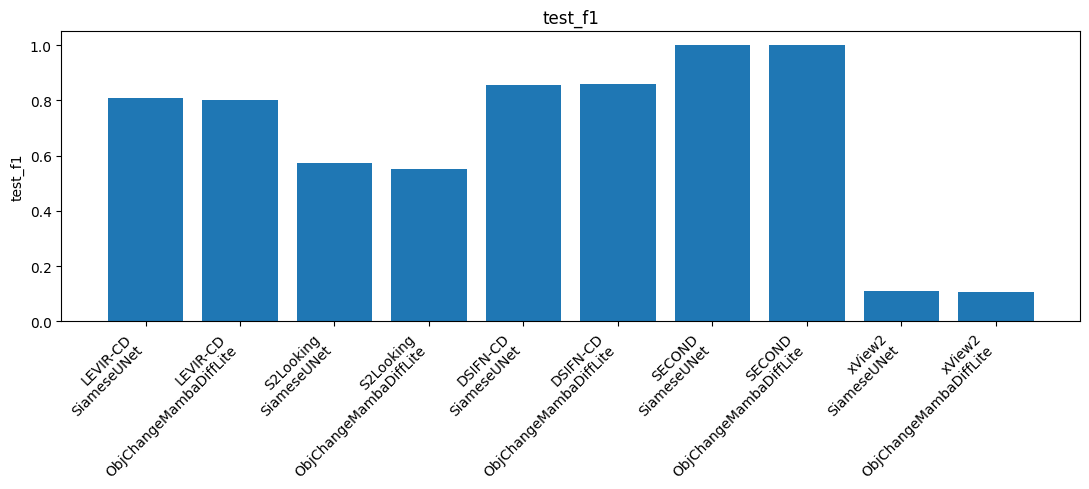

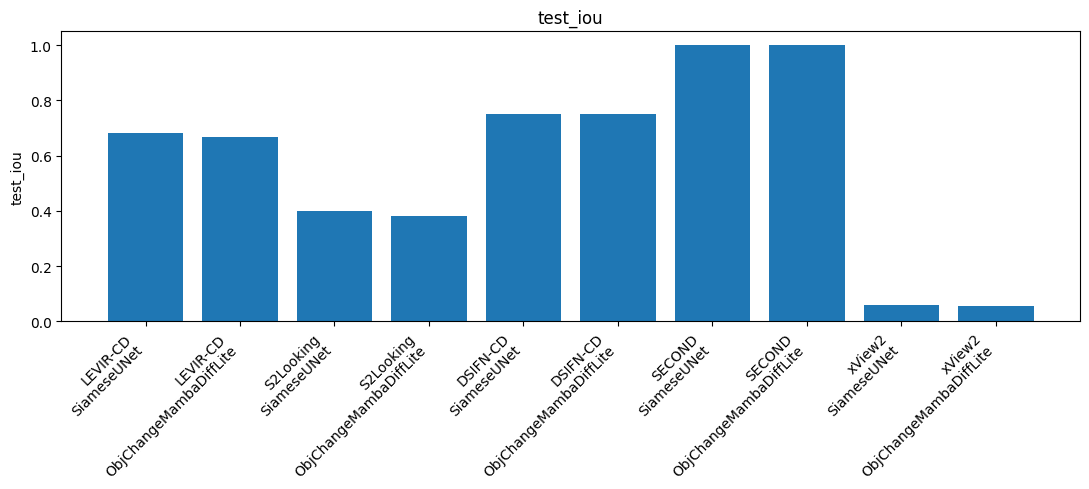

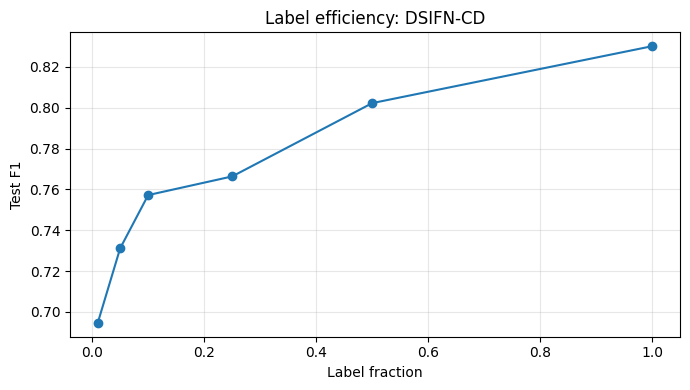

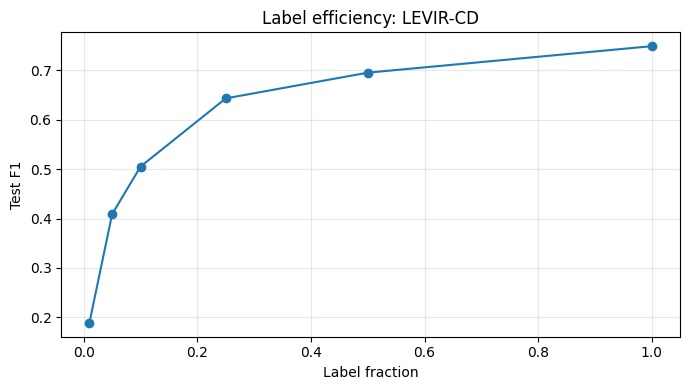

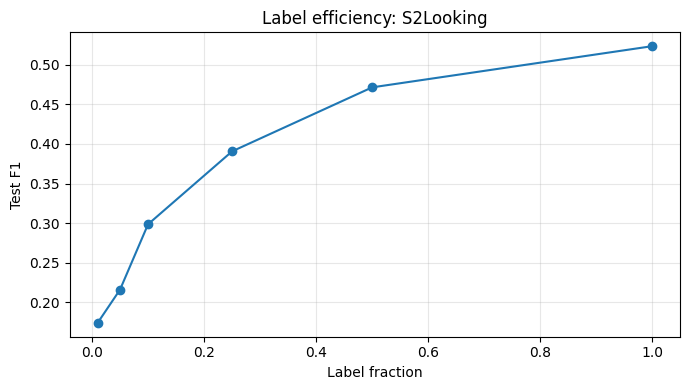

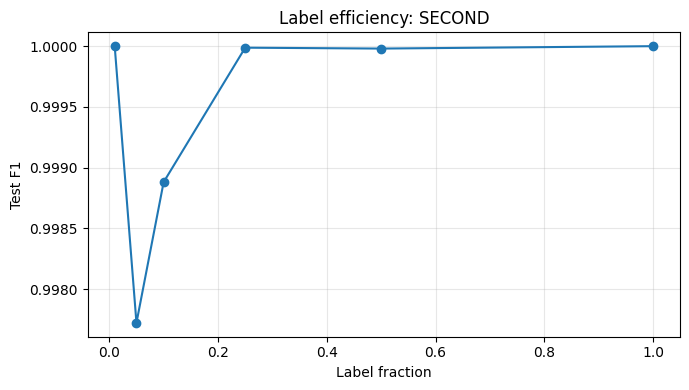

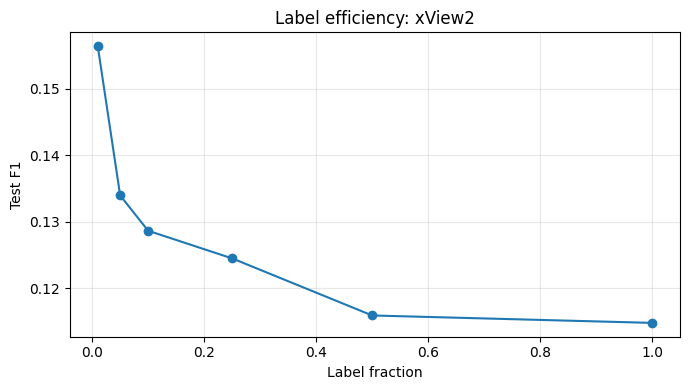

,experiment,dataset,model,epochs,best_val_f1,test_precision,test_recall,test_f1,test_iou,test_accuracy,test_kappa,test_ece,test_loss,checkpoint,runtime_min,resume_note,label_fraction,label_samples,train_dataset,test_dataset
0,main,LEVIR-CD,SiameseUNet,50,0.814131,0.758657,0.869167,0.810161,0.680899,0.979246,0.799237,0.008113,0.669065,D:\Datasets\Satillate\_objchange_mambadiff_ful...,53.973774,NaN,NaN,NaN,NaN,NaN
1,main,LEVIR-CD,ObjChangeMambaDiffLite,50,0.808895,0.747861,0.860580,0.800271,0.667043,0.978113,0.788753,0.008882,0.712786,D:\Datasets\Satillate\_objchange_mambadiff_ful...,39.346173,NaN,NaN,NaN,NaN,NaN
2,main,S2Looking,SiameseUNet,50,0.612391,0.545782,0.601831,0.572438,0.400990,0.989118,0.566940,0.007174,0.779469,D:\Datasets\Satillate\_objchange_mambadiff_ful...,807.225805,NaN,NaN,NaN,NaN,NaN
3,main,S2Looking,ObjChangeMambaDiffLite,50,0.597204,0.496194,0.622233,0.552112,0.381322,0.987781,0.545997,0.008004,0.802679,D:\Datasets\Satillate\_objchange_mambadiff_ful...,1022.513203,NaN,NaN,NaN,NaN,NaN
4,main,DSIFN-CD,SiameseUNet,50,0.866761,0.849899,0.863381,0.856587,0.749150,0.904493,0.785002,0.032604,0.723385,D:\Datasets\Satillate\_objchange_mambadiff_ful...,3487.523082,NaN,NaN,NaN,NaN,NaN
5,main,DSIFN-CD,ObjChangeMambaDiffLite,resumed_extra_20,0.845727,0.816788,0.903065,0.857762,0.750949,0.901058,0.782201,0.038627,0.748697,D:\Datasets\Satillate\_objchange_mambadiff_ful...,120.571771,continued_from_checkpoint,NaN,NaN,NaN,NaN
6,main,SECOND,SiameseUNet,50,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.001154,0.000578,D:\Datasets\Satillate\_objchange_mambadiff_ful...,107.081357,NaN,NaN,NaN,NaN,NaN
7,main,SECOND,ObjChangeMambaDiffLite,50,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.008529,0.004283,D:\Datasets\Satillate\_objchange_mambadiff_ful...,104.237593,NaN,NaN,NaN,NaN,NaN
8,main,xView2,SiameseUNet,50,0.827300,0.090544,0.139218,0.109725,0.058047,0.888074,0.052860,0.081549,6.942049,D:\Datasets\Satillate\_objchange_mambadiff_ful...,204.160448,NaN,NaN,NaN,NaN,NaN
9,main,xView2,ObjChangeMambaDiffLite,50,0.814394,0.091526,0.132703,0.108334,0.057269,0.891773,0.052788,0.075430,7.014338,D:\Datasets\Satillate\_objchange_mambadiff_ful...,288.028667,NaN,NaN,NaN,NaN,NaN


Saved consolidated results: D:\Datasets\Satillate\_objchange_mambadiff_full_experiment\reports\ALL_RESULTS_CONSOLIDATED.csv
{
  "root": "D:\\Datasets\\Satillate",
  "output_dir": "D:\\Datasets\\Satillate\\_objchange_mambadiff_full_experiment",
  "detected_datasets": [
    "DSIFN-CD",
    "LEVIR-CD",
    "S2Looking",
    "SECOND",
    "xView2"
  ],
  "selected_datasets": [
    "LEVIR-CD",
    "S2Looking",
    "DSIFN-CD",
    "SECOND",
    "xView2"
  ],
  "total_paired_records": 30159,
  "main_rows": 10,
  "label_efficiency_rows": 30,
  "cross_dataset_rows": 2,
  "ablation_rows": 5,
  "consolidated_rows": 47,
  "config": {
    "ROOT": "D:\\Datasets\\Satillate",
    "PROJECT_NAME": "_objchange_mambadiff_full_experiment",
    "SELECTED_DATASETS": [
      "LEVIR-CD",
      "S2Looking",
      "DSIFN-CD",
      "SECOND",
      "xView2"
    ],
    "IMAGE_SIZE": 256,
    "BATCH_SIZE": 4,
    "NUM_WORKERS": 0,
    "EPOCHS": 50,
    "LR": 0.0001,
    "WEIGHT_DECAY": 0.0001,
    "AMP": true,
    "

In [12]:

# ============================================================
# 11R. FINAL FIGURES, CONSOLIDATED CSV AND SUMMARY
# ============================================================

def safe_load_csv(p):
    p = Path(p)
    return pd.read_csv(p) if p.exists() else pd.DataFrame()

main_df = safe_load_csv(OUT_DIR / "reports" / "main_benchmark_results.csv")
label_df = safe_load_csv(OUT_DIR / "reports" / "label_efficiency_results.csv")
cross_df = safe_load_csv(OUT_DIR / "reports" / "cross_dataset_results.csv")
ablation_df = safe_load_csv(OUT_DIR / "reports" / "ablation_results.csv")

def plot_main_bar(df, metric, fname):
    if df is None or len(df) == 0 or metric not in df:
        return
    plt.figure(figsize=(11, 5))
    labels = [f"{r.dataset}\n{r.model}" for r in df.itertuples()]
    plt.bar(range(len(df)), df[metric])
    plt.xticks(range(len(df)), labels, rotation=45, ha="right")
    plt.ylabel(metric)
    plt.title(metric)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "figures" / fname, dpi=180)
    plt.show()

if len(main_df):
    plot_main_bar(main_df, "test_f1", "main_test_f1.png")
    plot_main_bar(main_df, "test_iou", "main_test_iou.png")

if len(label_df):
    for ds, sub in label_df.groupby("dataset"):
        sub = sub.sort_values("label_fraction")
        plt.figure(figsize=(7, 4))
        plt.plot(sub["label_fraction"], sub["test_f1"], marker="o")
        plt.grid(True, alpha=0.3)
        plt.xlabel("Label fraction")
        plt.ylabel("Test F1")
        plt.title(f"Label efficiency: {ds}")
        plt.tight_layout()
        plt.savefig(OUT_DIR / "figures" / f"label_efficiency_{ds}.png".replace("/", "_"), dpi=180)
        plt.show()

frames = []
for df in [main_df, label_df, cross_df, ablation_df]:
    if isinstance(df, pd.DataFrame) and len(df):
        frames.append(df)

if frames:
    consolidated = pd.concat(frames, ignore_index=True, sort=False)
    consolidated.to_csv(OUT_DIR / "reports" / "ALL_RESULTS_CONSOLIDATED.csv", index=False)
    display(consolidated.head(50))
    print("Saved consolidated results:", OUT_DIR / "reports" / "ALL_RESULTS_CONSOLIDATED.csv")
else:
    consolidated = pd.DataFrame()
    print("No result CSVs found yet.")

summary = {
    "root": str(ROOT),
    "output_dir": str(OUT_DIR),
    "detected_datasets": detected_datasets,
    "selected_datasets": selected,
    "total_paired_records": len(all_records),
    "main_rows": int(len(main_df)),
    "label_efficiency_rows": int(len(label_df)),
    "cross_dataset_rows": int(len(cross_df)),
    "ablation_rows": int(len(ablation_df)),
    "consolidated_rows": int(len(consolidated)),
    "config": asdict(cfg)
}
with open(OUT_DIR / "reports" / "experiment_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, default=str)

print(json.dumps(summary, indent=2, default=str))
print("\nFINAL OUTPUT FOLDER:")
print(OUT_DIR)
print("\nImportant files:")
for p in [
    OUT_DIR / "reports" / "main_benchmark_results.csv",
    OUT_DIR / "reports" / "label_efficiency_results.csv",
    OUT_DIR / "reports" / "cross_dataset_results.csv",
    OUT_DIR / "reports" / "ablation_results.csv",
    OUT_DIR / "reports" / "ALL_RESULTS_CONSOLIDATED.csv",
    OUT_DIR / "reports" / "experiment_summary.json",
]:
    print(p, "exists=", p.exists())
